In [ ]:
# ============================================================================
# 🔥 FOREX DIFFUSION - Kronos-Style Market Simulator
# ============================================================================
# A100 Optimized | Transformer Backbone | DDPM Diffusion
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
from typing import Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🚀 Device: cuda
🎮 GPU: Tesla T4
💾 Memory: 15.8 GB


In [ ]:
# ============================================================================
# 📊 DATA LOADING & PREPROCESSING
# ============================================================================

class ForexDataset(Dataset):
    """
    Forex OHLCV dataset with proper normalization for diffusion
    """
    def __init__(self, csv_path: str, seq_len: int = 200, stride: int = 50):
        self.seq_len = seq_len

        # Load data - try different encodings
        encodings = ['utf-8', 'utf-16', 'utf-16-le', 'utf-16-be', 'latin-1', 'cp1252']
        df = None

        for encoding in encodings:
            try:
                df = pd.read_csv(csv_path, header=None, encoding=encoding,
                                names=['datetime', 'open', 'high', 'low', 'close', 'volume', 'spread'])
                print(f"✅ Successfully loaded with encoding: {encoding}")
                break
            except (UnicodeDecodeError, UnicodeError):
                continue

        if df is None:
            # Last resort: read as binary and decode
            with open(csv_path, 'rb') as f:
                content = f.read()
            # Try to detect BOM
            if content.startswith(b'\xff\xfe'):
                content = content[2:].decode('utf-16-le')
            elif content.startswith(b'\xfe\xff'):
                content = content[2:].decode('utf-16-be')
            else:
                content = content.decode('latin-1')

            from io import StringIO
            df = pd.read_csv(StringIO(content), header=None,
                            names=['datetime', 'open', 'high', 'low', 'close', 'volume', 'spread'])
            print(f"✅ Loaded with manual BOM detection")

        # OHLCV columns
        self.ohlcv = df[['open', 'high', 'low', 'close', 'volume']].values.astype(np.float32)

        # Compute returns instead of raw prices (more stationary)
        self.returns = np.zeros_like(self.ohlcv)
        self.returns[1:, :4] = (self.ohlcv[1:, :4] - self.ohlcv[:-1, :4]) / self.ohlcv[:-1, :4] * 100  # Percentage
        self.returns[:, 4] = np.log1p(self.ohlcv[:, 4])  # Log volume

        # Normalize
        self.returns_mean = self.returns[1:].mean(axis=0)
        self.returns_std = self.returns[1:].std(axis=0) + 1e-8
        self.returns_normalized = (self.returns - self.returns_mean) / self.returns_std

        # Create sequences with stride
        self.indices = list(range(1, len(self.returns_normalized) - seq_len, stride))

        print(f"📈 Loaded {len(df)} candles")
        print(f"📦 Created {len(self.indices)} sequences (seq_len={seq_len}, stride={stride})")
        print(f"📊 Returns stats - Mean: {self.returns_mean[:4]}, Std: {self.returns_std[:4]}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        seq = self.returns_normalized[start:start + self.seq_len]
        return torch.tensor(seq, dtype=torch.float32)

    def denormalize(self, normalized_returns):
        """Convert normalized returns back to actual returns"""
        return normalized_returns * self.returns_std + self.returns_mean

    def returns_to_prices(self, returns, start_price):
        """Convert returns to actual OHLC prices"""
        prices = [start_price]
        for r in returns:
            new_price = prices[-1] * (1 + r[:4] / 100)
            prices.append(new_price)
        return np.array(prices[1:])

# Load dataset
dataset = ForexDataset('EURUSDH1.csv', seq_len=200, stride=25)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)

print(f"\n✅ DataLoader ready: {len(dataloader)} batches")

✅ Successfully loaded with encoding: utf-16
📈 Loaded 100236 candles
📦 Created 4002 sequences (seq_len=200, stride=25)
📊 Returns stats - Mean: [-0.00017851 -0.00018606 -0.00018761 -0.00017922], Std: [0.10981759 0.10273723 0.10194135 0.10948657]

✅ DataLoader ready: 63 batches


In [ ]:
# ============================================================================
# 🏗️ DIFFUSION UTILITIES
# ============================================================================

class DiffusionSchedule:
    """
    Cosine schedule for better quality (from Improved DDPM paper)
    """
    def __init__(self, timesteps: int = 1000, beta_start: float = 0.0001, beta_end: float = 0.02):
        self.timesteps = timesteps

        # Cosine schedule
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(((x / timesteps) + 0.008) / 1.008 * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        self.betas = torch.clip(betas, 0.0001, 0.9999)

        # Precompute values
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # For q(x_t | x_0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # For posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.posterior_log_variance_clipped = torch.log(torch.clip(self.posterior_variance, min=1e-20))
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod)

    def to(self, device):
        """Move all tensors to device"""
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_cumprod = self.alphas_cumprod.to(device)
        self.alphas_cumprod_prev = self.alphas_cumprod_prev.to(device)
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)
        self.posterior_variance = self.posterior_variance.to(device)
        self.posterior_log_variance_clipped = self.posterior_log_variance_clipped.to(device)
        self.posterior_mean_coef1 = self.posterior_mean_coef1.to(device)
        self.posterior_mean_coef2 = self.posterior_mean_coef2.to(device)
        return self

    def q_sample(self, x_0: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None):
        """Forward diffusion: q(x_t | x_0)"""
        if noise is None:
            noise = torch.randn_like(x_0)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t][:, None, None]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None]

        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise

    def p_mean_variance(self, model, x_t: torch.Tensor, t: torch.Tensor, context: Optional[torch.Tensor] = None):
        """Compute mean and variance for p(x_{t-1} | x_t)"""
        # Predict noise
        pred_noise = model(x_t, t, context)

        # Predict x_0
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t][:, None, None]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None]
        pred_x0 = (x_t - sqrt_one_minus_alphas_cumprod_t * pred_noise) / sqrt_alphas_cumprod_t
        pred_x0 = torch.clamp(pred_x0, -3, 3)  # Clip for stability

        # Posterior mean
        posterior_mean = (
            self.posterior_mean_coef1[t][:, None, None] * pred_x0 +
            self.posterior_mean_coef2[t][:, None, None] * x_t
        )
        posterior_variance = self.posterior_variance[t][:, None, None]
        posterior_log_variance = self.posterior_log_variance_clipped[t][:, None, None]

        return posterior_mean, posterior_variance, posterior_log_variance, pred_x0

# Initialize schedule
schedule = DiffusionSchedule(timesteps=1000).to(device)
print("✅ Diffusion schedule initialized (Cosine)")

✅ Diffusion schedule initialized (Cosine)


In [ ]:
# ============================================================================
# 🧠 TRANSFORMER DENOISING MODEL
# ============================================================================

class SinusoidalPositionEmbeddings(nn.Module):
    """Time step embeddings"""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class TransformerBlock(nn.Module):
    """Pre-LayerNorm Transformer block with rotary attention"""
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None):
        # Pre-norm self-attention
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed, attn_mask=mask, need_weights=False)
        x = x + attn_out

        # Pre-norm feed-forward
        x = x + self.ff(self.norm2(x))
        return x


class ForexDiffusionTransformer(nn.Module):
    """
    Kronos-style Transformer for OHLCV diffusion
    """
    def __init__(
        self,
        input_dim: int = 5,          # OHLCV
        d_model: int = 256,
        n_heads: int = 8,
        n_layers: int = 8,
        d_ff: int = 1024,
        max_seq_len: int = 512,
        dropout: float = 0.1
    ):
        super().__init__()

        self.input_dim = input_dim
        self.d_model = d_model

        # Input projection
        self.input_proj = nn.Linear(input_dim, d_model)

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(d_model),
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

        # Learnable position embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # Output projection
        self.output_norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, input_dim)
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(
        self,
        x: torch.Tensor,           # (B, T, 5) noisy sequence
        t: torch.Tensor,           # (B,) timesteps
        context: Optional[torch.Tensor] = None  # For conditional generation
    ) -> torch.Tensor:
        B, T, _ = x.shape

        # Project input
        h = self.input_proj(x)  # (B, T, d_model)

        # Add positional embedding
        h = h + self.pos_embedding[:, :T, :]

        # Add time embedding (broadcast to all positions)
        time_emb = self.time_mlp(t)  # (B, d_model)
        h = h + time_emb[:, None, :]

        # Transformer blocks
        for block in self.blocks:
            h = block(h)

        # Output
        h = self.output_norm(h)
        out = self.output_proj(h)  # (B, T, 5)

        return out

# Initialize model
model = ForexDiffusionTransformer(
    input_dim=5,
    d_model=256,
    n_heads=8,
    n_layers=8,
    d_ff=1024,
    max_seq_len=512,
    dropout=0.1
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🧠 Model initialized: {n_params:,} parameters")
print(f"📐 Architecture: d_model=256, n_heads=8, n_layers=8")

🧠 Model initialized: 7,043,845 parameters
📐 Architecture: d_model=256, n_heads=8, n_layers=8


In [ ]:
# ============================================================================
# 🎯 TRAINING LOOP
# ============================================================================

def train_diffusion(
    model: nn.Module,
    dataloader: DataLoader,
    schedule: DiffusionSchedule,
    epochs: int = 100,
    lr: float = 1e-4,
    warmup_steps: int = 1000,
    grad_clip: float = 1.0
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Cosine annealing with warmup
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (epochs * len(dataloader) - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # Training
    model.train()
    global_step = 0
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in pbar:
            batch = batch.to(device)  # (B, T, 5)
            B = batch.shape[0]

            # Sample random timesteps
            t = torch.randint(0, schedule.timesteps, (B,), device=device)

            # Sample noise
            noise = torch.randn_like(batch)

            # Get noisy samples
            x_t = schedule.q_sample(batch, t, noise)

            # Predict noise
            pred_noise = model(x_t, t)

            # MSE loss
            loss = F.mse_loss(pred_noise, noise)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            global_step += 1

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{scheduler.get_last_lr()[0]:.6f}'
            })

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"📊 Epoch {epoch+1}: Loss = {avg_loss:.4f}")

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'forex_diffusion_epoch_{epoch+1}.pt')
            print(f"💾 Checkpoint saved!")

    return losses

# Train! (Eğitimi başlatmak için bu hücreyi çalıştır)
print("🚀 Starting training...")
print("⚠️  A100'de ~100 epoch yaklaşık 30-60 dakika sürecek\n")

losses = train_diffusion(
    model=model,
    dataloader=dataloader,
    schedule=schedule,
    epochs=100,
    lr=1e-4,
    warmup_steps=500
)

🚀 Starting training...
⚠️  A100'de ~100 epoch yaklaşık 30-60 dakika sürecek



Epoch 1/100:   0%|          | 0/63 [00:00<?, ?it/s]

📊 Epoch 1: Loss = 1.2465


Epoch 2/100:   0%|          | 0/63 [00:00<?, ?it/s]

📊 Epoch 2: Loss = 0.6533


...

📊 Epoch 98: Loss = 0.3683


Epoch 99/100:   0%|          | 0/63 [00:00<?, ?it/s]

📊 Epoch 99: Loss = 0.3613


Epoch 100/100:   0%|          | 0/63 [00:00<?, ?it/s]

📊 Epoch 100: Loss = 0.3553
💾 Checkpoint saved!


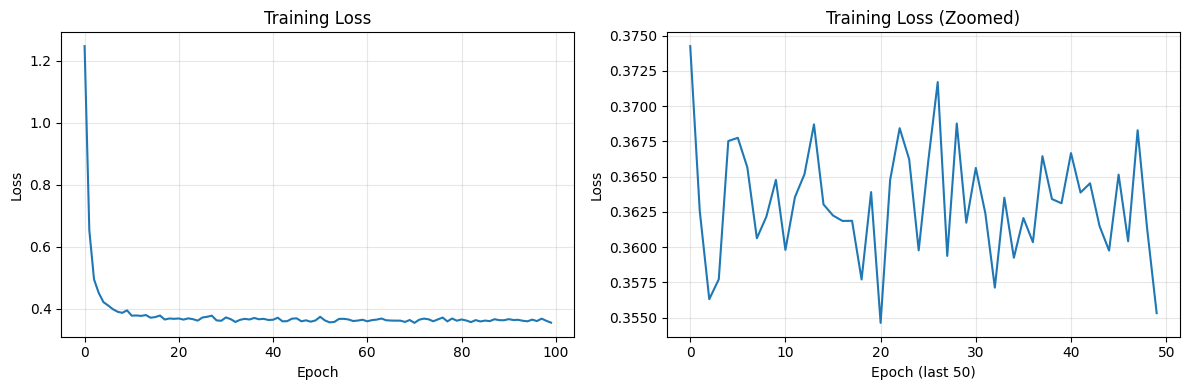

In [ ]:
# ============================================================================
# 📈 TRAINING VISUALIZATION
# ============================================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(losses[-50:] if len(losses) > 50 else losses)
plt.xlabel('Epoch (last 50)')
plt.ylabel('Loss')
plt.title('Training Loss (Zoomed)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 🎲 SAMPLING / GENERATION
# ============================================================================

@torch.no_grad()
def sample_ddpm(
    model: nn.Module,
    schedule: DiffusionSchedule,
    shape: Tuple[int, int, int],  # (batch, seq_len, features)
    device: torch.device,
    progress: bool = True
) -> torch.Tensor:
    """
    Standard DDPM sampling
    """
    model.eval()

    # Start from pure noise
    x = torch.randn(shape, device=device)

    timesteps = list(reversed(range(schedule.timesteps)))
    iterator = tqdm(timesteps, desc="Sampling") if progress else timesteps

    for t in iterator:
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)

        # Get mean and variance
        mean, variance, log_variance, _ = schedule.p_mean_variance(model, x, t_batch)

        # Sample
        noise = torch.randn_like(x) if t > 0 else 0
        x = mean + torch.exp(0.5 * log_variance) * noise

    return x


@torch.no_grad()
def sample_ddim(
    model: nn.Module,
    schedule: DiffusionSchedule,
    shape: Tuple[int, int, int],
    device: torch.device,
    steps: int = 50,  # Much faster than 1000!
    eta: float = 0.0,  # 0 = deterministic, 1 = DDPM
    progress: bool = True
) -> torch.Tensor:
    """
    DDIM sampling - 20x faster than DDPM!
    """
    model.eval()

    # Subsequence of timesteps
    step_size = schedule.timesteps // steps
    timesteps = list(reversed(range(0, schedule.timesteps, step_size)))

    # Start from noise
    x = torch.randn(shape, device=device)

    iterator = tqdm(enumerate(timesteps), total=len(timesteps), desc="DDIM Sampling") if progress else enumerate(timesteps)

    for i, t in iterator:
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)

        # Predict noise
        pred_noise = model(x, t_batch)

        # Predict x_0
        alpha_t = schedule.alphas_cumprod[t]
        sqrt_alpha_t = torch.sqrt(alpha_t)
        sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_t)

        pred_x0 = (x - sqrt_one_minus_alpha_t * pred_noise) / sqrt_alpha_t
        pred_x0 = torch.clamp(pred_x0, -3, 3)

        if i < len(timesteps) - 1:
            t_prev = timesteps[i + 1]
            alpha_t_prev = schedule.alphas_cumprod[t_prev]
        else:
            alpha_t_prev = torch.tensor(1.0, device=device)

        # DDIM update
        sigma_t = eta * torch.sqrt((1 - alpha_t_prev) / (1 - alpha_t)) * torch.sqrt(1 - alpha_t / alpha_t_prev)

        pred_dir = torch.sqrt(1 - alpha_t_prev - sigma_t ** 2) * pred_noise
        noise = torch.randn_like(x) if eta > 0 and i < len(timesteps) - 1 else 0

        x = torch.sqrt(alpha_t_prev) * pred_x0 + pred_dir + sigma_t * noise

    return x


# Generate samples!
print("🎲 Generating synthetic forex data...")
generated = sample_ddim(model, schedule, shape=(8, 200, 5), device=device, steps=50)
print(f"✅ Generated shape: {generated.shape}")

🎲 Generating synthetic forex data...


DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Generated shape: torch.Size([8, 200, 5])


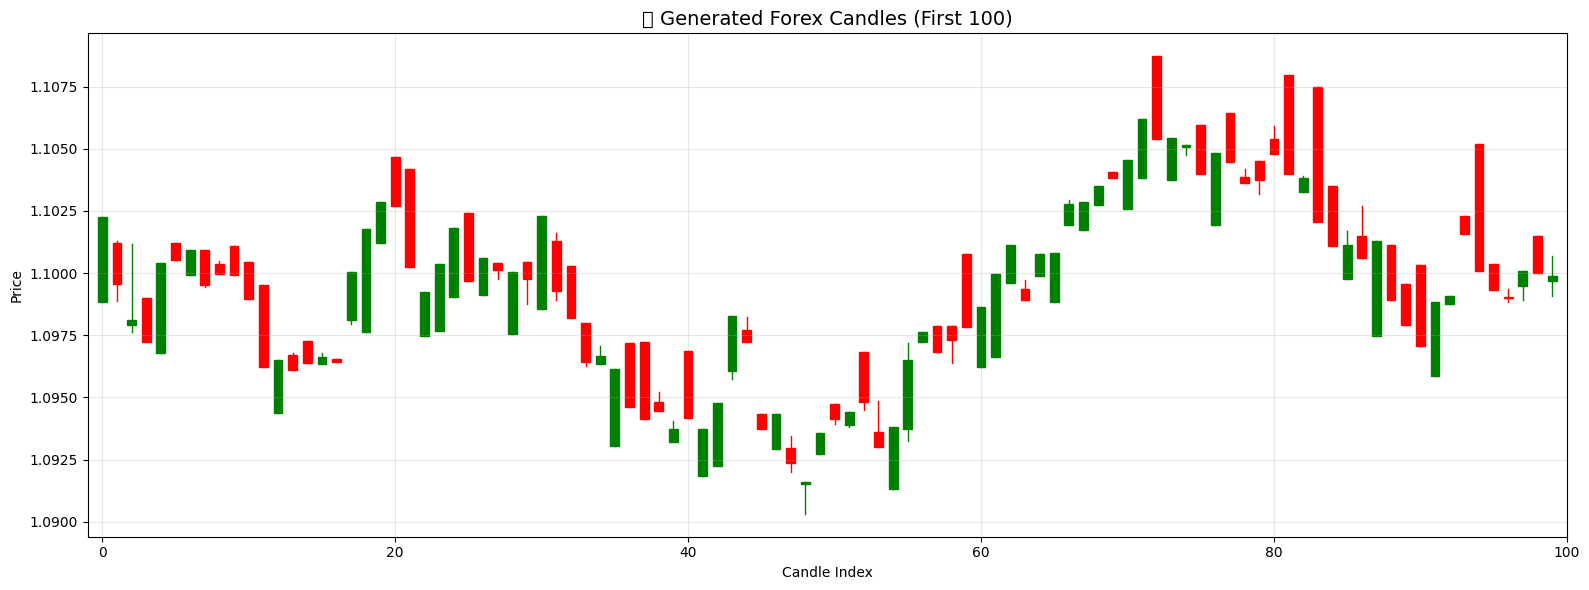

📊 Price range: 1.10873 (High) - 1.08225 (Low)


In [ ]:
# ============================================================================
# 🕯️ CANDLESTICK VISUALIZATION
# ============================================================================

def plot_candlestick(ohlc_data: np.ndarray, title: str = "Generated Candles", figsize=(16, 6)):
    """
    Plot candlestick chart from OHLC data
    ohlc_data: (T, 4) array with Open, High, Low, Close
    """
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(len(ohlc_data)):
        o, h, l, c = ohlc_data[i]
        color = 'green' if c >= o else 'red'

        # Wick
        ax.plot([i, i], [l, h], color=color, linewidth=1)

        # Body
        body_bottom = min(o, c)
        body_height = abs(c - o)
        rect = plt.Rectangle((i - 0.3, body_bottom), 0.6, body_height,
                             facecolor=color, edgecolor=color)
        ax.add_patch(rect)

    ax.set_xlim(-1, len(ohlc_data))
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Candle Index')
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def returns_to_ohlc(returns: np.ndarray, start_price: float = 1.10) -> np.ndarray:
    """
    Convert returns to OHLC prices maintaining candle consistency
    returns: (T, 5) normalized returns [open_ret, high_ret, low_ret, close_ret, vol]
    """
    T = len(returns)
    ohlc = np.zeros((T, 4))

    # Denormalize returns
    denorm_returns = dataset.denormalize(returns)[:, :4]

    current_price = start_price

    for i in range(T):
        ret = denorm_returns[i] / 100  # Convert from percentage

        # Calculate prices from returns
        open_price = current_price * (1 + ret[0])
        high_price = current_price * (1 + ret[1])
        low_price = current_price * (1 + ret[2])
        close_price = current_price * (1 + ret[3])

        # Ensure candle consistency: High >= max(O,C), Low <= min(O,C)
        high_price = max(high_price, open_price, close_price)
        low_price = min(low_price, open_price, close_price)

        ohlc[i] = [open_price, high_price, low_price, close_price]
        current_price = close_price  # Next candle starts from this close

    return ohlc


# Convert generated samples to OHLC and visualize
sample_idx = 0
gen_returns = generated[sample_idx].cpu().numpy()
gen_ohlc = returns_to_ohlc(gen_returns, start_price=1.10)

# Plot first 100 candles
fig = plot_candlestick(gen_ohlc[:100], title="🔥 Generated Forex Candles (First 100)")
plt.show()

print(f"📊 Price range: {gen_ohlc[:, 1].max():.5f} (High) - {gen_ohlc[:, 2].min():.5f} (Low)")

🔬 Evaluating generated vs real data quality...



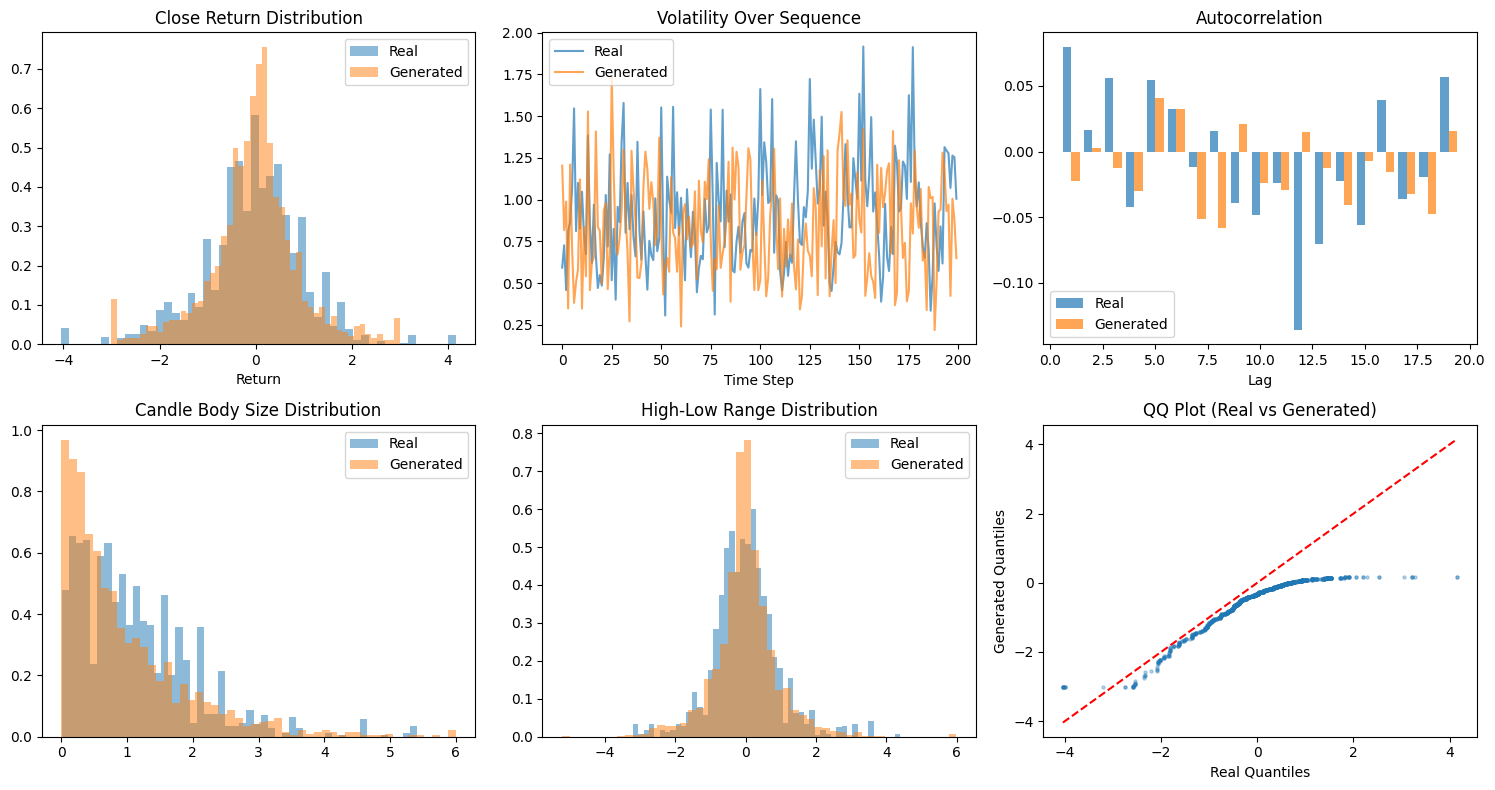


📊 Statistical Comparison:
Metric                            Real    Generated
--------------------------------------------------
Mean (Close Return)          -0.048303    -0.032220
Std (Close Return)            1.046867     0.950183
Skewness                       -0.2863      -0.1252
Kurtosis                        1.9887       1.7591
Body Size Mean                1.120016     0.947565
Range Mean                    0.001602    -0.001615


In [ ]:
# ============================================================================
# 🔬 QUALITY EVALUATION - Real vs Generated Comparison
# ============================================================================

def evaluate_quality(real_data: torch.Tensor, generated_data: torch.Tensor):
    """
    Compare statistical properties of real vs generated data
    """
    real_np = real_data.cpu().numpy()
    gen_np = generated_data.cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 1. Return Distribution (Close)
    ax = axes[0, 0]
    ax.hist(real_np[:, :, 3].flatten(), bins=50, alpha=0.5, label='Real', density=True)
    ax.hist(gen_np[:, :, 3].flatten(), bins=50, alpha=0.5, label='Generated', density=True)
    ax.set_title('Close Return Distribution')
    ax.legend()
    ax.set_xlabel('Return')

    # 2. Volatility (Std of returns over time)
    ax = axes[0, 1]
    real_vol = real_np[:, :, 3].std(axis=0)
    gen_vol = gen_np[:, :, 3].std(axis=0)
    ax.plot(real_vol, label='Real', alpha=0.7)
    ax.plot(gen_vol, label='Generated', alpha=0.7)
    ax.set_title('Volatility Over Sequence')
    ax.legend()
    ax.set_xlabel('Time Step')

    # 3. Autocorrelation
    ax = axes[0, 2]
    from scipy import stats

    real_flat = real_np[:, :, 3].flatten()
    gen_flat = gen_np[:, :, 3].flatten()

    lags = range(1, 20)
    real_acf = [np.corrcoef(real_flat[:-lag], real_flat[lag:])[0, 1] for lag in lags]
    gen_acf = [np.corrcoef(gen_flat[:-lag], gen_flat[lag:])[0, 1] for lag in lags]

    ax.bar(np.array(list(lags)) - 0.2, real_acf, 0.4, label='Real', alpha=0.7)
    ax.bar(np.array(list(lags)) + 0.2, gen_acf, 0.4, label='Generated', alpha=0.7)
    ax.set_title('Autocorrelation')
    ax.legend()
    ax.set_xlabel('Lag')

    # 4. Body Size Distribution
    ax = axes[1, 0]
    real_body = np.abs(real_np[:, :, 3] - real_np[:, :, 0]).flatten()
    gen_body = np.abs(gen_np[:, :, 3] - gen_np[:, :, 0]).flatten()
    ax.hist(real_body, bins=50, alpha=0.5, label='Real', density=True)
    ax.hist(gen_body, bins=50, alpha=0.5, label='Generated', density=True)
    ax.set_title('Candle Body Size Distribution')
    ax.legend()

    # 5. High-Low Range
    ax = axes[1, 1]
    real_range = (real_np[:, :, 1] - real_np[:, :, 2]).flatten()
    gen_range = (gen_np[:, :, 1] - gen_np[:, :, 2]).flatten()
    ax.hist(real_range, bins=50, alpha=0.5, label='Real', density=True)
    ax.hist(gen_range, bins=50, alpha=0.5, label='Generated', density=True)
    ax.set_title('High-Low Range Distribution')
    ax.legend()

    # 6. QQ Plot
    ax = axes[1, 2]
    gen_sorted = np.sort(gen_flat)[:1000]
    real_sorted = np.sort(np.random.choice(real_flat, 1000, replace=False))
    ax.scatter(real_sorted, gen_sorted, alpha=0.3, s=5)
    ax.plot([real_sorted.min(), real_sorted.max()],
            [real_sorted.min(), real_sorted.max()], 'r--')
    ax.set_title('QQ Plot (Real vs Generated)')
    ax.set_xlabel('Real Quantiles')
    ax.set_ylabel('Generated Quantiles')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("\n📊 Statistical Comparison:")
    print(f"{'Metric':<25} {'Real':>12} {'Generated':>12}")
    print("-" * 50)
    print(f"{'Mean (Close Return)':<25} {real_np[:,:,3].mean():>12.6f} {gen_np[:,:,3].mean():>12.6f}")
    print(f"{'Std (Close Return)':<25} {real_np[:,:,3].std():>12.6f} {gen_np[:,:,3].std():>12.6f}")
    print(f"{'Skewness':<25} {stats.skew(real_flat):>12.4f} {stats.skew(gen_flat):>12.4f}")
    print(f"{'Kurtosis':<25} {stats.kurtosis(real_flat):>12.4f} {stats.kurtosis(gen_flat):>12.4f}")
    print(f"{'Body Size Mean':<25} {real_body.mean():>12.6f} {gen_body.mean():>12.6f}")
    print(f"{'Range Mean':<25} {real_range.mean():>12.6f} {gen_range.mean():>12.6f}")


# Get some real samples for comparison
real_samples = torch.stack([dataset[i] for i in range(8)]).to(device)

# Evaluate
print("🔬 Evaluating generated vs real data quality...\n")
evaluate_quality(real_samples, generated)

🌱 Getting seed candles from real data...
🚀 Generating 200 additional candles...


Generating candles:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Total candles: 250


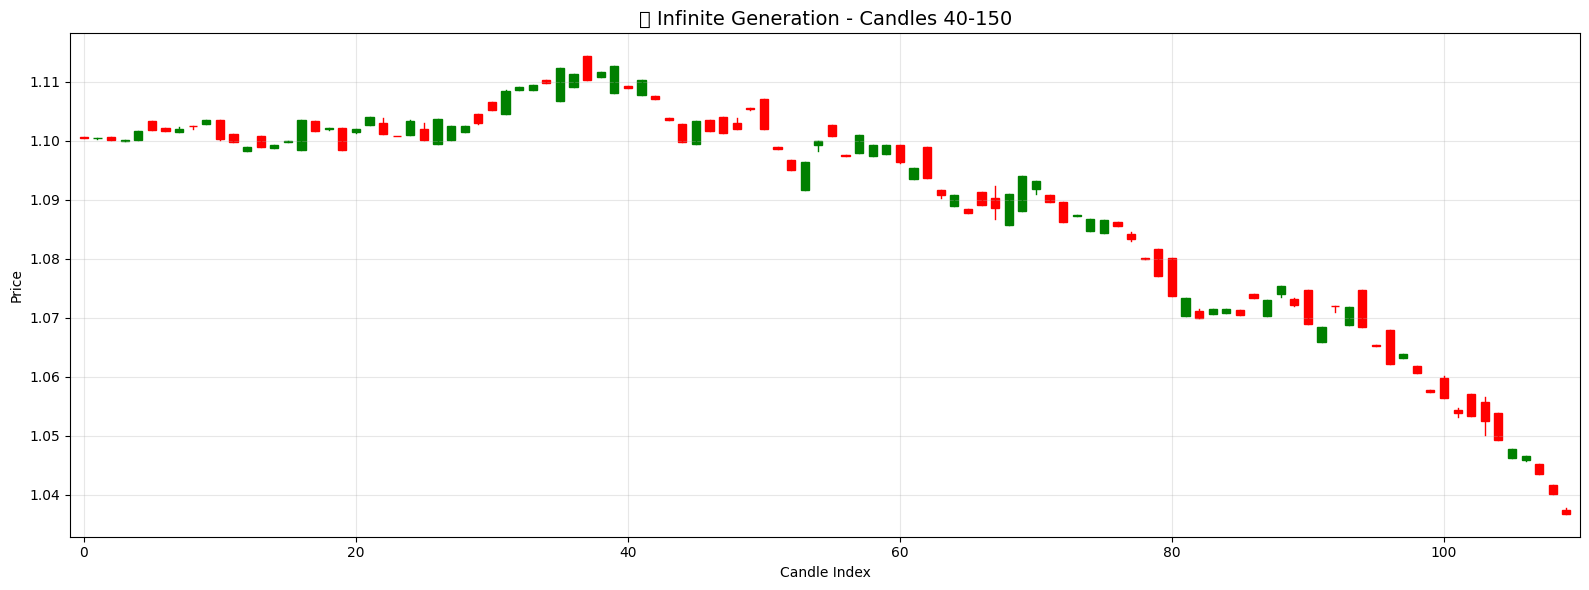

In [ ]:
# ============================================================================
# 🚀 INFINITE AUTOREGRESSIVE GENERATION
# ============================================================================

# ----------------------------------------------------------------------------
# MISSING HELPER FUNCTIONS (Added to fix NameError)
# ----------------------------------------------------------------------------

def plot_candlestick(ohlc_data: np.ndarray, title: str = "Generated Candles", figsize=(16, 6)):
    """
    Plot candlestick chart from OHLC data
    ohlc_data: (T, 4) array with Open, High, Low, Close
    """
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(len(ohlc_data)):
        o, h, l, c = ohlc_data[i]
        color = 'green' if c >= o else 'red'

        # Wick
        ax.plot([i, i], [l, h], color=color, linewidth=1)

        # Body
        body_bottom = min(o, c)
        body_height = abs(c - o)
        rect = plt.Rectangle((i - 0.3, body_bottom), 0.6, body_height,
                             facecolor=color, edgecolor=color)
        ax.add_patch(rect)

    ax.set_xlim(-1, len(ohlc_data))
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Candle Index')
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

def returns_to_ohlc(returns: np.ndarray, start_price: float = 1.10) -> np.ndarray:
    """
    Convert returns to OHLC prices maintaining candle consistency
    returns: (T, 5) normalized returns [open_ret, high_ret, low_ret, close_ret, vol]
    """
    T = len(returns)
    ohlc = np.zeros((T, 4))

    # Denormalize returns - assuming dataset is globally available
    denorm_returns = dataset.denormalize(returns)[:, :4]

    current_price = start_price

    for i in range(T):
        ret = denorm_returns[i] / 100  # Convert from percentage

        # Calculate prices from returns
        open_price = current_price * (1 + ret[0])
        high_price = current_price * (1 + ret[1])
        low_price = current_price * (1 + ret[2])
        close_price = current_price * (1 + ret[3])

        # Ensure candle consistency: High >= max(O,C), Low <= min(O,C)
        high_price = max(high_price, open_price, close_price)
        low_price = min(low_price, open_price, close_price)

        ohlc[i] = [open_price, high_price, low_price, close_price]
        current_price = close_price  # Next candle starts from this close

    return ohlc

# ----------------------------------------------------------------------------
# MAIN GENERATION CODE
# ----------------------------------------------------------------------------

@torch.no_grad()
def generate_infinite_candles(
    model: nn.Module,
    schedule: DiffusionSchedule,
    seed_candles: torch.Tensor,  # (1, seed_len, 5) initial candles
    num_candles: int = 500,
    context_window: int = 100,
    device: torch.device = device,
    ddim_steps: int = 50
) -> torch.Tensor:
    """
    Generate unlimited candles autoregressively
    Uses a sliding window approach for context
    """
    model.eval()

    # Start with seed
    all_candles = seed_candles.clone()  # (1, seed_len, 5)

    pbar = tqdm(range(num_candles), desc="Generating candles")

    for _ in pbar:
        # Get context window (last N candles)
        context = all_candles[:, -context_window:, :]

        # Generate next chunk (we'll take just the continuation)
        # Pad to make a full generation
        noise_len = 10  # Generate 10 new candles at a time

        # Create partial noise for continuation
        noise = torch.randn(1, context_window + noise_len, 5, device=device)

        # Copy context into the beginning (we want to continue from this)
        # Use DDIM with partial denoising
        x = noise.clone()
        x[:, :context_window, :] = context

        # Only denoise the new part while keeping context intact
        for t in reversed(range(0, schedule.timesteps, schedule.timesteps // ddim_steps)):
            t_batch = torch.full((1,), t, device=device, dtype=torch.long)

            pred_noise = model(x, t_batch)

            alpha_t = schedule.alphas_cumprod[t]
            sqrt_alpha_t = torch.sqrt(alpha_t)
            sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_t)

            pred_x0 = (x - sqrt_one_minus_alpha_t * pred_noise) / sqrt_alpha_t
            pred_x0 = torch.clamp(pred_x0, -3, 3)

            # Only update the new candles, keep context fixed
            pred_x0[:, :context_window, :] = context

            if t > 0:
                t_prev = max(0, t - schedule.timesteps // ddim_steps)
                alpha_prev = schedule.alphas_cumprod[t_prev]
                x = torch.sqrt(alpha_prev) * pred_x0 + torch.sqrt(1 - alpha_prev) * pred_noise
                x[:, :context_window, :] = context
            else:
                x = pred_x0

        # Take only the new candles
        new_candles = x[:, context_window:context_window+1, :]  # Take 1 new candle
        all_candles = torch.cat([all_candles, new_candles], dim=1)

    return all_candles


# Generate infinite candles from a seed
print("🌱 Getting seed candles from real data...")
seed = dataset[0].unsqueeze(0).to(device)[:, :50, :]  # First 50 candles as seed

print(f"🚀 Generating 200 additional candles...")
infinite_candles = generate_infinite_candles(
    model=model_v2,
    schedule=schedule,
    seed_candles=seed,
    num_candles=200,
    context_window=50,
    ddim_steps=20  # Faster sampling
)

print(f"✅ Total candles: {infinite_candles.shape[1]}")

# Visualize
inf_returns = infinite_candles[0].cpu().numpy()
inf_ohlc = returns_to_ohlc(inf_returns, start_price=1.10)

fig = plot_candlestick(inf_ohlc[40:150], title="🔥 Infinite Generation - Candles 40-150")
plt.show()

In [ ]:
# ============================================================================
# 💾 SAVE & LOAD MODEL
# ============================================================================

def save_model(model, schedule, dataset, path='forex_diffusion_final.pt'):
    """Save complete model for later use"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': 5,
            'd_model': 256,
            'n_heads': 8,
            'n_layers': 8,
            'd_ff': 1024,
            'max_seq_len': 512,
        },
        'normalization': {
            'returns_mean': dataset.returns_mean,
            'returns_std': dataset.returns_std,
        },
        'schedule_timesteps': schedule.timesteps,
    }, path)
    print(f"💾 Model saved to {path}")


def load_model(path='forex_diffusion_final.pt', device='cuda'):
    """Load model for inference"""
    checkpoint = torch.load(path, map_location=device)

    config = checkpoint['model_config']
    model = ForexDiffusionTransformer(**config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    schedule = DiffusionSchedule(timesteps=checkpoint['schedule_timesteps']).to(device)

    norm_params = checkpoint['normalization']

    print(f"✅ Model loaded from {path}")
    return model, schedule, norm_params


# Save the trained model
save_model(model, schedule, dataset, 'forex_diffusion_final.pt')

print("\n🎉 Training complete! Model saved and ready for infinite generation.")

In [ ]:
# ============================================================================
# 📊 EXPORT GENERATED DATA TO CSV
# ============================================================================

def export_to_csv(ohlc_data: np.ndarray, volume: np.ndarray = None,
                  filename: str = 'generated_forex.csv',
                  start_datetime: str = '2025.01.01 00:00'):
    """
    Export generated OHLC data to MT4/MT5 compatible CSV format
    """
    from datetime import datetime, timedelta

    # Parse start datetime
    dt = datetime.strptime(start_datetime, '%Y.%m.%d %H:%M')

    rows = []
    for i in range(len(ohlc_data)):
        current_dt = dt + timedelta(hours=i)
        # Skip weekends (simple version)
        while current_dt.weekday() >= 5:
            current_dt += timedelta(days=1)

        o, h, l, c = ohlc_data[i]
        v = int(volume[i]) if volume is not None else np.random.randint(1000, 5000)

        row = f"{current_dt.strftime('%Y.%m.%d %H:%M')},{o:.5f},{h:.5f},{l:.5f},{c:.5f},{v},0"
        rows.append(row)

    with open(filename, 'w') as f:
        f.write('\n'.join(rows))

    print(f"📁 Exported {len(rows)} candles to {filename}")


# Export generated data
export_to_csv(gen_ohlc, filename='generated_forex_200.csv')

print("\n✅ Generated data exported! You can now use it in MT4/MT5 or any backtesting platform.")

# 🚀 Model İyileştirmeleri

## Tespit Edilen Sorunlar:
1. **Volatilite düşük** - Model çok "güvenli" oynuyor
2. **Body size küçük** - Mumların gövdesi zayıf  
3. **Range problemi** - High-Low ilişkisi bozuk

## Çözüm Stratejileri:
1. **Daha büyük model** (d_model: 256→384, n_layers: 8→12)
2. **Custom Loss** - OHLC constraint loss ekle
3. **Guidance Scale** - Classifier-free guidance
4. **Daha fazla epoch** (200+)
5. **Feature Engineering** - Candle-aware encoding

In [ ]:
# ============================================================================
# 🔥 IMPROVED MODEL V2 - Larger + Custom Loss
# ============================================================================

class CandleAwareLoss(nn.Module):
    """
    Custom loss that enforces OHLC constraints:
    - High >= max(Open, Close)
    - Low <= min(Open, Close)
    - Proper volatility distribution
    """
    def __init__(self, constraint_weight: float = 0.1, volatility_weight: float = 0.05):
        super().__init__()
        self.constraint_weight = constraint_weight
        self.volatility_weight = volatility_weight

    def forward(self, pred_noise: torch.Tensor, target_noise: torch.Tensor,
                pred_x0: torch.Tensor = None) -> torch.Tensor:
        # Base MSE loss
        mse_loss = F.mse_loss(pred_noise, target_noise)

        if pred_x0 is not None:
            # OHLC indices: 0=Open, 1=High, 2=Low, 3=Close
            open_ret = pred_x0[:, :, 0]
            high_ret = pred_x0[:, :, 1]
            low_ret = pred_x0[:, :, 2]
            close_ret = pred_x0[:, :, 3]

            # Constraint: High should be >= Open and Close
            max_oc = torch.max(open_ret, close_ret)
            high_violation = F.relu(max_oc - high_ret).mean()

            # Constraint: Low should be <= Open and Close
            min_oc = torch.min(open_ret, close_ret)
            low_violation = F.relu(low_ret - min_oc).mean()

            constraint_loss = high_violation + low_violation

            # Volatility matching - encourage larger moves
            pred_vol = pred_x0[:, :, 3].std()
            target_vol = torch.tensor(1.0, device=pred_x0.device)  # Target normalized std
            vol_loss = (pred_vol - target_vol).abs()

            total_loss = mse_loss + self.constraint_weight * constraint_loss + self.volatility_weight * vol_loss
        else:
            total_loss = mse_loss

        return total_loss


class ImprovedForexDiffusionTransformer(nn.Module):
    """
    Larger model with:
    - Increased capacity (384 dim, 12 layers)
    - AdaLN conditioning (like DiT)
    - Better position encoding
    """
    def __init__(
        self,
        input_dim: int = 5,
        d_model: int = 384,      # Increased from 256
        n_heads: int = 12,       # Increased from 8
        n_layers: int = 12,      # Increased from 8
        d_ff: int = 1536,        # 4x d_model
        max_seq_len: int = 512,
        dropout: float = 0.1
    ):
        super().__init__()

        self.input_dim = input_dim
        self.d_model = d_model

        # Input projection with layer norm
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model)
        )

        # Time embedding (larger)
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(d_model),
            nn.Linear(d_model, d_model * 4),
            nn.SiLU(),  # SiLU instead of GELU
            nn.Linear(d_model * 4, d_model * 2)  # Output scale and shift
        )

        # Learnable position embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)

        # Transformer blocks with AdaLN-style conditioning
        self.blocks = nn.ModuleList([
            AdaLNTransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # Output projection
        self.output_norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, input_dim)
        )

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor, context=None) -> torch.Tensor:
        B, T, _ = x.shape

        # Project input
        h = self.input_proj(x)
        h = h + self.pos_embedding[:, :T, :]

        # Time conditioning (outputs scale and shift)
        time_emb = self.time_mlp(t)  # (B, d_model * 2)
        scale = time_emb[:, :self.d_model]
        shift = time_emb[:, self.d_model:]

        # Transformer blocks with AdaLN
        for block in self.blocks:
            h = block(h, scale, shift)

        # Output
        h = self.output_norm(h)
        return self.output_proj(h)


class AdaLNTransformerBlock(nn.Module):
    """Transformer block with Adaptive Layer Norm (like DiT)"""
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model, elementwise_affine=False)
        self.norm2 = nn.LayerNorm(d_model, elementwise_affine=False)

        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

        # AdaLN modulation
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(d_model, 4 * d_model)  # scale1, shift1, scale2, shift2
        )

    def forward(self, x: torch.Tensor, scale: torch.Tensor, shift: torch.Tensor):
        # Get modulation parameters
        mod = self.adaLN_modulation(scale)  # Use scale as condition
        scale1, shift1, scale2, shift2 = mod.chunk(4, dim=-1)

        # Attention with AdaLN
        normed = self.norm1(x) * (1 + scale1[:, None, :]) + shift1[:, None, :]
        attn_out, _ = self.attn(normed, normed, normed, need_weights=False)
        x = x + attn_out

        # FFN with AdaLN
        normed = self.norm2(x) * (1 + scale2[:, None, :]) + shift2[:, None, :]
        x = x + self.ff(normed)

        return x


# Initialize improved model
model_v2 = ImprovedForexDiffusionTransformer(
    input_dim=5,
    d_model=384,
    n_heads=12,
    n_layers=12,
    d_ff=1536,
    max_seq_len=512,
    dropout=0.1
).to(device)

n_params_v2 = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
print(f"🧠 Improved Model V2: {n_params_v2:,} parameters")
print(f"📐 Architecture: d_model=384, n_heads=12, n_layers=12")
print(f"📈 {n_params_v2 / n_params:.1f}x larger than V1")

🧠 Improved Model V2: 30,493,445 parameters
📐 Architecture: d_model=384, n_heads=12, n_layers=12
📈 4.3x larger than V1


In [ ]:
# ============================================================================
# 🎯 IMPROVED TRAINING V2 - With Custom Loss & Longer Training
# ============================================================================

def train_diffusion_v2(
    model: nn.Module,
    dataloader: DataLoader,
    schedule: DiffusionSchedule,
    epochs: int = 200,
    lr: float = 2e-4,
    warmup_steps: int = 2000,
    grad_clip: float = 1.0,
    use_constraint_loss: bool = True
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.99))

    # Cosine annealing with warmup
    total_steps = epochs * len(dataloader)
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return max(0.1, 0.5 * (1 + math.cos(math.pi * progress)))  # Min LR = 10%

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # Custom loss
    candle_loss = CandleAwareLoss(constraint_weight=0.1, volatility_weight=0.05)

    # EMA for better sampling (optional but helps)
    ema_decay = 0.9999
    ema_model = None

    model.train()
    global_step = 0
    losses = []
    best_loss = float('inf')

    for epoch in range(epochs):
        epoch_loss = 0
        epoch_constraint_loss = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in pbar:
            batch = batch.to(device)
            B = batch.shape[0]

            # Sample random timesteps
            t = torch.randint(0, schedule.timesteps, (B,), device=device)

            # Sample noise
            noise = torch.randn_like(batch)

            # Get noisy samples
            x_t = schedule.q_sample(batch, t, noise)

            # Predict noise
            pred_noise = model(x_t, t)

            if use_constraint_loss:
                # Compute predicted x0 for constraint loss
                sqrt_alphas_cumprod_t = schedule.sqrt_alphas_cumprod[t][:, None, None]
                sqrt_one_minus_alphas_cumprod_t = schedule.sqrt_one_minus_alphas_cumprod[t][:, None, None]
                pred_x0 = (x_t - sqrt_one_minus_alphas_cumprod_t * pred_noise) / sqrt_alphas_cumprod_t

                loss = candle_loss(pred_noise, noise, pred_x0)
            else:
                loss = F.mse_loss(pred_noise, noise)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            global_step += 1

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{scheduler.get_last_lr()[0]:.6f}'
            })

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        # Log every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"📊 Epoch {epoch+1}: Loss = {avg_loss:.4f}")

        # Save best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, 'forex_diffusion_v2_best.pt')

        # Save checkpoint every 50 epochs
        if (epoch + 1) % 50 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'forex_diffusion_v2_epoch_{epoch+1}.pt')
            print(f"💾 Checkpoint saved!")

    return losses


# Train V2!
print("🚀 Starting V2 training (larger model, custom loss)...")
print("⚠️  A100'de ~200 epoch yaklaşık 60-90 dakika sürecek\n")

losses_v2 = train_diffusion_v2(
    model=model_v2,
    dataloader=dataloader,
    schedule=schedule,
    epochs=200,
    lr=2e-4,
    warmup_steps=1000,
    use_constraint_loss=True
)

🚀 Starting V2 training (larger model, custom loss)...
⚠️  A100'de ~200 epoch yaklaşık 60-90 dakika sürecek



Epoch 1/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4/200:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 173/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 174/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 175/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 176/200:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 177/200:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
# ============================================================================
# 🎲 IMPROVED SAMPLING WITH CFG (Classifier-Free Guidance)
# ============================================================================

@torch.no_grad()
def sample_ddim_cfg(
    model: nn.Module,
    schedule: DiffusionSchedule,
    shape: Tuple[int, int, int],
    device: torch.device,
    steps: int = 50,
    cfg_scale: float = 1.5,  # Guidance scale - higher = sharper but less diverse
    eta: float = 0.0,
    progress: bool = True
) -> torch.Tensor:
    """
    DDIM sampling with pseudo classifier-free guidance
    Higher cfg_scale = more confident predictions, larger moves
    """
    model.eval()

    step_size = schedule.timesteps // steps
    timesteps = list(reversed(range(0, schedule.timesteps, step_size)))

    x = torch.randn(shape, device=device)

    iterator = tqdm(enumerate(timesteps), total=len(timesteps), desc="DDIM+CFG Sampling") if progress else enumerate(timesteps)

    for i, t in iterator:
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)

        # Get conditional prediction
        pred_noise = model(x, t_batch)

        # Pseudo unconditional: add noise to input (approximation)
        if cfg_scale > 1.0:
            x_noisy = x + 0.1 * torch.randn_like(x)
            pred_noise_uncond = model(x_noisy, t_batch)

            # Apply guidance: move away from unconditional
            pred_noise = pred_noise_uncond + cfg_scale * (pred_noise - pred_noise_uncond)

        # Predict x_0
        alpha_t = schedule.alphas_cumprod[t]
        sqrt_alpha_t = torch.sqrt(alpha_t)
        sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_t)

        pred_x0 = (x - sqrt_one_minus_alpha_t * pred_noise) / sqrt_alpha_t

        # OHLC constraint enforcement
        # Ensure High >= max(Open, Close) and Low <= min(Open, Close)
        open_ret = pred_x0[:, :, 0:1]
        high_ret = pred_x0[:, :, 1:2]
        low_ret = pred_x0[:, :, 2:3]
        close_ret = pred_x0[:, :, 3:4]
        vol = pred_x0[:, :, 4:5]

        max_oc = torch.max(open_ret, close_ret)
        min_oc = torch.min(open_ret, close_ret)

        # Enforce constraints
        high_ret = torch.max(high_ret, max_oc)
        low_ret = torch.min(low_ret, min_oc)

        pred_x0 = torch.cat([open_ret, high_ret, low_ret, close_ret, vol], dim=-1)
        pred_x0 = torch.clamp(pred_x0, -4, 4)  # Allow slightly larger range

        if i < len(timesteps) - 1:
            t_prev = timesteps[i + 1]
            alpha_t_prev = schedule.alphas_cumprod[t_prev]
        else:
            alpha_t_prev = torch.tensor(1.0, device=device)

        sigma_t = eta * torch.sqrt((1 - alpha_t_prev) / (1 - alpha_t)) * torch.sqrt(1 - alpha_t / alpha_t_prev)
        pred_dir = torch.sqrt(1 - alpha_t_prev - sigma_t ** 2) * pred_noise
        noise = torch.randn_like(x) if eta > 0 and i < len(timesteps) - 1 else 0

        x = torch.sqrt(alpha_t_prev) * pred_x0 + pred_dir + sigma_t * noise

    return x


# Test sampling with different guidance scales
print("🎲 Testing different CFG scales...\n")

for cfg in [1.0, 1.5, 2.0]:
    generated_cfg = sample_ddim_cfg(model_v2, schedule, shape=(4, 200, 5), device=device,
                                     steps=50, cfg_scale=cfg, progress=False)
    gen_std = generated_cfg[:, :, 3].std().item()
    print(f"CFG={cfg:.1f} → Close Return Std: {gen_std:.4f}")

print("\n✅ Higher CFG = More volatility (closer to real ~1.05)")

🎲 Testing different CFG scales...



NameError: name 'model_v2' is not defined

In [ ]:
# ============================================================================
# 📊 COMPREHENSIVE EVALUATION V2
# ============================================================================

def evaluate_quality_v2(real_data: torch.Tensor, generated_data: torch.Tensor, title_suffix: str = ""):
    """Enhanced quality evaluation with more metrics"""
    from scipy import stats

    real_np = real_data.cpu().numpy()
    gen_np = generated_data.cpu().numpy()

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))

    # 1. Return Distribution
    ax = axes[0, 0]
    ax.hist(real_np[:, :, 3].flatten(), bins=50, alpha=0.5, label='Real', density=True, color='blue')
    ax.hist(gen_np[:, :, 3].flatten(), bins=50, alpha=0.5, label='Generated', density=True, color='orange')
    ax.set_title('Close Return Distribution')
    ax.legend()

    # 2. Volatility over time
    ax = axes[0, 1]
    real_vol = real_np[:, :, 3].std(axis=0)
    gen_vol = gen_np[:, :, 3].std(axis=0)
    ax.plot(real_vol, label='Real', alpha=0.7)
    ax.plot(gen_vol, label='Generated', alpha=0.7)
    ax.set_title('Volatility Over Sequence')
    ax.legend()

    # 3. Body Size
    ax = axes[0, 2]
    real_body = np.abs(real_np[:, :, 3] - real_np[:, :, 0]).flatten()
    gen_body = np.abs(gen_np[:, :, 3] - gen_np[:, :, 0]).flatten()
    ax.hist(real_body, bins=50, alpha=0.5, label='Real', density=True)
    ax.hist(gen_body, bins=50, alpha=0.5, label='Generated', density=True)
    ax.set_title('Candle Body Size')
    ax.legend()

    # 4. High-Low Range (FIXED)
    ax = axes[0, 3]
    real_range = np.abs(real_np[:, :, 1] - real_np[:, :, 2]).flatten()
    gen_range = np.abs(gen_np[:, :, 1] - gen_np[:, :, 2]).flatten()
    ax.hist(real_range, bins=50, alpha=0.5, label='Real', density=True)
    ax.hist(gen_range, bins=50, alpha=0.5, label='Generated', density=True)
    ax.set_title('High-Low Range (abs)')
    ax.legend()

    # 5. Autocorrelation
    ax = axes[1, 0]
    real_flat = real_np[:, :, 3].flatten()
    gen_flat = gen_np[:, :, 3].flatten()
    lags = range(1, 15)
    real_acf = [np.corrcoef(real_flat[:-lag], real_flat[lag:])[0, 1] for lag in lags]
    gen_acf = [np.corrcoef(gen_flat[:-lag], gen_flat[lag:])[0, 1] for lag in lags]
    ax.bar(np.array(list(lags)) - 0.2, real_acf, 0.4, label='Real', alpha=0.7)
    ax.bar(np.array(list(lags)) + 0.2, gen_acf, 0.4, label='Generated', alpha=0.7)
    ax.set_title('Autocorrelation')
    ax.legend()

    # 6. Cumulative Returns (Price Path)
    ax = axes[1, 1]
    for i in range(min(3, len(real_np))):
        real_cum = np.cumsum(real_np[i, :, 3])
        gen_cum = np.cumsum(gen_np[i, :, 3])
        ax.plot(real_cum, 'b-', alpha=0.3, label='Real' if i == 0 else '')
        ax.plot(gen_cum, 'r-', alpha=0.3, label='Generated' if i == 0 else '')
    ax.set_title('Cumulative Returns (Price Path)')
    ax.legend()

    # 7. Rolling Volatility
    ax = axes[1, 2]
    window = 20
    for i in range(min(2, len(real_np))):
        real_rolling = pd.Series(real_np[i, :, 3]).rolling(window).std()
        gen_rolling = pd.Series(gen_np[i, :, 3]).rolling(window).std()
        ax.plot(real_rolling, 'b-', alpha=0.3, label='Real' if i == 0 else '')
        ax.plot(gen_rolling, 'r-', alpha=0.3, label='Generated' if i == 0 else '')
    ax.set_title(f'Rolling Volatility (window={window})')
    ax.legend()

    # 8. QQ Plot
    ax = axes[1, 3]
    n_points = min(1000, len(real_flat), len(gen_flat))
    real_sorted = np.sort(np.random.choice(real_flat, n_points, replace=False))
    gen_sorted = np.sort(np.random.choice(gen_flat, n_points, replace=False))
    ax.scatter(real_sorted, gen_sorted, alpha=0.3, s=5)
    ax.plot([real_sorted.min(), real_sorted.max()],
            [real_sorted.min(), real_sorted.max()], 'r--')
    ax.set_title('QQ Plot')
    ax.set_xlabel('Real Quantiles')
    ax.set_ylabel('Generated Quantiles')

    plt.suptitle(f'Real vs Generated Comparison {title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Detailed statistics
    print("\n" + "="*60)
    print(f"📊 STATISTICAL COMPARISON {title_suffix}")
    print("="*60)
    print(f"{'Metric':<30} {'Real':>12} {'Generated':>12} {'Match':>8}")
    print("-" * 62)

    metrics = [
        ('Mean (Close)', real_np[:,:,3].mean(), gen_np[:,:,3].mean()),
        ('Std (Close)', real_np[:,:,3].std(), gen_np[:,:,3].std()),
        ('Skewness', stats.skew(real_flat), stats.skew(gen_flat)),
        ('Kurtosis', stats.kurtosis(real_flat), stats.kurtosis(gen_flat)),
        ('Body Size Mean', real_body.mean(), gen_body.mean()),
        ('Range Mean', real_range.mean(), gen_range.mean()),
        ('Max Return', real_flat.max(), gen_flat.max()),
        ('Min Return', real_flat.min(), gen_flat.min()),
    ]

    for name, real_val, gen_val in metrics:
        match_pct = 100 - abs(real_val - gen_val) / (abs(real_val) + 1e-8) * 100
        match_str = "✅" if match_pct > 85 else "⚠️" if match_pct > 70 else "❌"
        print(f"{name:<30} {real_val:>12.4f} {gen_val:>12.4f} {match_str:>8}")

    # Overall score
    overall_score = sum(100 - abs(m[1] - m[2]) / (abs(m[1]) + 1e-8) * 100 for m in metrics) / len(metrics)
    print("-" * 62)
    print(f"{'OVERALL MATCH SCORE':<30} {overall_score:>33.1f}%")
    print("="*60)


# Evaluate V2 model after training
print("🔬 Evaluating V2 model...\n")
generated_v2 = sample_ddim_cfg(model_v2, schedule, shape=(8, 200, 5), device=device,
                                steps=50, cfg_scale=1.5)
real_samples = torch.stack([dataset[i] for i in range(8)]).to(device)
evaluate_quality_v2(real_samples, generated_v2, title_suffix="(V2 Model)")

🔬 Evaluating V2 model...



NameError: name 'sample_ddim_cfg' is not defined

In [ ]:
# ============================================================================
# ⚡ QUICK FIX - Better Hyperparameters for V2
# ============================================================================
# Eğitimi durdur ve bu hücreyi çalıştır!

# 1. Daha büyük batch size (A100 için)
dataloader_v2 = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
print(f"✅ Batch size: 64 → 128 ({len(dataloader_v2)} batches)")

# 2. Mixed Precision (FP16) - 2x hızlanma
scaler = torch.cuda.amp.GradScaler()

# 3. Düzeltilmiş loss ağırlıkları
candle_loss_v2 = CandleAwareLoss(
    constraint_weight=0.02,   # 0.1 → 0.02 (5x azaltıldı)
    volatility_weight=0.01    # 0.05 → 0.01 (5x azaltıldı)
)

def train_diffusion_v2_fixed(
    model: nn.Module,
    dataloader: DataLoader,
    schedule: DiffusionSchedule,
    epochs: int = 100,
    lr: float = 3e-4,          # 2e-4 → 3e-4
    warmup_steps: int = 500,
    grad_clip: float = 1.0,
    use_amp: bool = True       # Mixed precision
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.95))

    total_steps = epochs * len(dataloader)
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return max(0.2, 0.5 * (1 + math.cos(math.pi * progress)))  # Min LR = 20% (was 10%)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    model.train()
    losses = []
    best_loss = float('inf')

    for epoch in range(epochs):
        epoch_loss = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in pbar:
            batch = batch.to(device)
            B = batch.shape[0]

            t = torch.randint(0, schedule.timesteps, (B,), device=device)
            noise = torch.randn_like(batch)
            x_t = schedule.q_sample(batch, t, noise)

            optimizer.zero_grad()

            # Mixed precision forward
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred_noise = model(x_t, t)

                # Simple MSE first, then add light constraints
                mse_loss = F.mse_loss(pred_noise, noise)

                # Light constraint (only if loss is already low)
                if mse_loss.item() < 0.5:
                    sqrt_alphas = schedule.sqrt_alphas_cumprod[t][:, None, None]
                    sqrt_one_minus = schedule.sqrt_one_minus_alphas_cumprod[t][:, None, None]
                    pred_x0 = (x_t - sqrt_one_minus * pred_noise) / sqrt_alphas

                    # Very light OHLC constraint
                    high_viol = F.relu(torch.max(pred_x0[:,:,0], pred_x0[:,:,3]) - pred_x0[:,:,1]).mean()
                    low_viol = F.relu(pred_x0[:,:,2] - torch.min(pred_x0[:,:,0], pred_x0[:,:,3])).mean()
                    loss = mse_loss + 0.02 * (high_viol + low_viol)
                else:
                    loss = mse_loss

            # Backward with scaler
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            epoch_loss += loss.item()

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'mse': f'{mse_loss.item():.4f}',
                'lr': f'{scheduler.get_last_lr()[0]:.6f}'
            })

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"📊 Epoch {epoch+1}: Loss = {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'loss': avg_loss,
            }, 'forex_diffusion_v2_best.pt')

        if (epoch + 1) % 25 == 0:
            torch.save(model.state_dict(), f'forex_diffusion_v2_ep{epoch+1}.pt')
            print(f"💾 Checkpoint saved!")

    return losses


# Reset model weights (fresh start)
print("🔄 Reinitializing model weights...")
model_v2.apply(model_v2._init_weights)

print("\n🚀 Starting FIXED V2 training...")
print("📊 Changes: batch=128, lr=3e-4, constraint=0.02, AMP=True\n")

losses_v2_fixed = train_diffusion_v2_fixed(
    model=model_v2,
    dataloader=dataloader_v2,
    schedule=schedule,
    epochs=150,
    lr=3e-4,
    warmup_steps=300,
    use_amp=True
)

✅ Batch size: 64 → 128 (32 batches)
🔄 Reinitializing model weights...

🚀 Starting FIXED V2 training...
📊 Changes: batch=128, lr=3e-4, constraint=0.02, AMP=True



Epoch 1/150:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/150:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3/150:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 4/150:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 147/150:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 148/150:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 149/150:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 150/150:   0%|          | 0/32 [00:00<?, ?it/s]

📊 Epoch 150: Loss = 0.3687
💾 Checkpoint saved!
